# Aula 8 – Análise de Sentimentos – Exemplo 4 (Transformers)

**Objetivo:** evoluir a Análise de Sentimentos para uma abordagem baseada em **Transformers**, mantendo a sequência didática e aproximando o processo de práticas profissionais.

Neste notebook, avançamos em relação aos exemplos anteriores:

- deixamos de usar *features* manuais (Bag-of-Words/TF-IDF);
- passamos a usar um **modelo de linguagem pré-treinado** que representa o texto de forma contextual;
- realizamos:
  1) **inferência** com modelo pré-treinado (uso profissional mais comum);
  2) (opcional) **fine-tuning** com dados rotulados (adaptação ao domínio).

Ao final, avaliamos com métricas e discutimos limitações (negação, ironia, domínio, vieses).

## 1. Setup

Este notebook utiliza a biblioteca **Transformers** (Hugging Face).  
É necessário baixar um modelo pré-treinado na primeira execução.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Análise do resultado:
- Torch: 2.9.0+cpu: o PyTorch instalado é a versão CPU-only. A CPU usada é a CPU dos servidores do Google. Modelos de aprendizado de máquina rodam de forma mais lenta do que em GPUs (Graphics Processing Unit).

- CUDA disponível: False: CUDA é uma plataforma de computação paralela desenvolvida pela NVIDIA que permite que GPUs  realizem cálculos de forma muito mais rápida.

In [4]:
# Caso esteja em ambiente local/Colab e precise instalar:
!pip -q install transformers datasets accelerate evaluate torch

import torch
print("Torch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00
Torch: 2.9.0+cpu
CUDA disponível: False


## 2. Dados

Para manter a continuidade didática, usamos um mini-corpus rotulado.

Em projetos reais, esta etapa seria substituída por um dataset maior e mais representativo do domínio.

In [14]:
textos = [
    # positivos
    "O produto é ótimo",
    "O produto é excelente",
    "Gostei muito do produto",
    "A experiência foi excelente",
    "Atendimento rápido e ótimo",
    "Serviço muito bom",
    "Entrega foi rápida e ótima",
    "Estou satisfeito com o atendimento",
    "O sistema funciona muito bem",
    "Valeu a pena comprar",
    "Qualidade muito boa e entrega rápida",
    "Suporte resolveu meu problema rapidamente",
    "Gostei do atendimento e do produto",
    "Compra excelente, recomendo",
    "Muito satisfeito com o serviço",
    "O atendimento foi eficiente e cordial",
    "A entrega chegou antes do prazo",
    "O produto atendeu minhas expectativas",
    "Funcionou perfeitamente desde o início",
    "Boa qualidade e bom atendimento",
    "Serviço ágil e sem complicações",
    "Sistema estável e fácil de usar",
    "Experiência positiva do começo ao fim",
    "Fiquei satisfeito com a compra realizada",
    "O suporte foi rápido e prestativo",

    # negativos
    "O produto é ruim",
    "O produto é péssimo",
    "Não gostei do produto",
    "A experiência foi ruim",
    "Atendimento lento e péssimo",
    "Serviço muito ruim",
    "A entrega foi atrasada e ruim",
    "Estou insatisfeito com o atendimento",
    "O sistema falha e é ruim",
    "Não valeu a pena comprar",
    "Qualidade ruim e entrega atrasada",
    "Suporte não resolveu meu problema",
    "Atendimento péssimo, não recomendo",
    "Compra ruim, fiquei insatisfeito",
    "Muito decepcionado com o serviço",
    "O atendimento demorou demais",
    "A entrega chegou com atraso",
    "O produto não funcionou corretamente",
    "Experiência negativa com o serviço",
    "Sistema instável e cheio de falhas",
    "Qualidade abaixo do esperado",
    "Não fiquei satisfeito com a compra",
    "O suporte foi ineficiente",
    "Serviço confuso e mal organizado",
    "Tive problemas desde o início",
]
# rótulos
sentimentos = np.array([1]*25 + [0]*25)
print("N:", len(textos), "| positivo:", int(sentimentos.sum()), "| negativo:", int((1-sentimentos).sum()))

N: 50 | positivo: 25 | negativo: 25


## Trilha A — Inferência profissional com modelo pré-treinado

## 3. Inferência com modelo pré-treinado (pipeline)

Nesta etapa, usamos um **classificador de sentimento pré-treinado**.
Isso é comum em aplicações profissionais quando:
- não há dados rotulados suficientes para fine-tuning;
- deseja-se rapidez na prototipação;
- busca-se uma baseline forte.

> Escolha do modelo: prefira um modelo de sentimento compatível com português (ou multilíngue).
> Caso o modelo retorne rótulos genéricos (LABEL_0/LABEL_1), discutimos a interpretação adiante.



In [15]:
from transformers import pipeline

# Exemplo: modelo multilíngue/português (ajuste conforme sua escolha)
# Se você já tiver um modelo preferido, substitua o "model=" abaixo.
sent_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

tests = [
    "A entrega foi boa",
    "Estou satisfeito com o produto",
    "Atendimento lento e péssimo",
    "Não gostei do produto",
    "Entrega rápida e ótima",
]

out = sent_pipe(tests)
for t, r in zip(tests, out):
    print(t, "->", r)

Device set to use cpu


A entrega foi boa -> {'label': 'positive', 'score': 0.773432195186615}
Estou satisfeito com o produto -> {'label': 'positive', 'score': 0.8662423491477966}
Atendimento lento e péssimo -> {'label': 'negative', 'score': 0.9480333924293518}
Não gostei do produto -> {'label': 'negative', 'score': 0.83501797914505}
Entrega rápida e ótima -> {'label': 'positive', 'score': 0.8751817941665649}


## 4. Padronização de saída e “incerteza”

Modelos pré-treinados podem retornar rótulos como `LABEL_0`, `LABEL_1` etc.
Em um fluxo profissional, padronizamos a saída:

- `predicao`: classe final (0/1)
- `score`: confiança
- `status`: marca “incerto” quando a confiança é baixa

> O limiar de incerteza depende do seu caso de uso e do custo de erros (FP/FN).


In [16]:
def prever_sentimento_transformer(texto, limiar_incerteza=0.60):
    r = sent_pipe(texto)[0]
    label = r["label"]
    score = float(r["score"])

    # Mapeamento: depende do modelo escolhido.
    # No modelo cardiffnlp/twitter-xlm-roberta-base-sentiment:
    # labels típicos: 'positive', 'neutral', 'negative'
    # Aqui vamos colapsar em binário (positivo vs negativo) e tratar neutral como incerto.
    if label.lower() == "positive":
        pred = 1
        status = "ok" if score >= limiar_incerteza else "incerto (baixa confiança)"
    elif label.lower() == "negative":
        pred = 0
        status = "ok" if score >= limiar_incerteza else "incerto (baixa confiança)"
    else:
        pred = None
        status = "incerto (neutro)"

    return {"texto": texto, "predicao": pred, "label": label, "score": score, "status": status}

for t in tests:
    print(prever_sentimento_transformer(t))


{'texto': 'A entrega foi boa', 'predicao': 1, 'label': 'positive', 'score': 0.773432195186615, 'status': 'ok'}
{'texto': 'Estou satisfeito com o produto', 'predicao': 1, 'label': 'positive', 'score': 0.8662423491477966, 'status': 'ok'}
{'texto': 'Atendimento lento e péssimo', 'predicao': 0, 'label': 'negative', 'score': 0.9480333924293518, 'status': 'ok'}
{'texto': 'Não gostei do produto', 'predicao': 0, 'label': 'negative', 'score': 0.83501797914505, 'status': 'ok'}
{'texto': 'Entrega rápida e ótima', 'predicao': 1, 'label': 'positive', 'score': 0.8751817941665649, 'status': 'ok'}


## Trilha B — Fine-tuning (opcional, mas excelente para fechar o “profissional”)

## 5. Fine-tuning supervisionado (opcional)

Aqui mostramos como adaptar um Transformer ao domínio com dados rotulados.
Mesmo com corpus pequeno, a célula serve para:
- mostrar o pipeline profissional de treinamento;
- destacar requisitos (dados, validação, métricas).

> Em produção, recomenda-se dataset maior e validação robusta.


In [17]:
from sklearn.model_selection import train_test_split

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    textos, sentimentos, test_size=0.30, random_state=RANDOM_STATE, stratify=sentimentos
)

print("Treino:", len(X_train_txt), "| Teste:", len(X_test_txt))

Treino: 35 | Teste: 15


In [18]:
from datasets import Dataset

train_ds = Dataset.from_dict({"text": X_train_txt, "label": y_train})
test_ds  = Dataset.from_dict({"text": X_test_txt,  "label": y_test})

train_ds, test_ds

(Dataset({
     features: ['text', 'label'],
     num_rows: 35
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 15
 }))

## 6. Tokenização

Transformers operam sobre tokens. A tokenização:
- converte texto em IDs
- aplica truncamento/padding
- prepara tensores para o modelo

In [19]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=128)

train_tok = train_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

train_tok = train_tok.remove_columns(["text"]).with_format("torch")
test_tok  = test_tok.remove_columns(["text"]).with_format("torch")

Map:   0%|          | 0/35 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

## 7. Fine-tuning com Trainer

Usamos um classificador (`AutoModelForSequenceClassification`) e o `Trainer`, que organiza:
- treino
- avaliação
- logging

A métrica principal aqui será F1 (como nos exemplos anteriores).

In [20]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

args = TrainingArguments(
    output_dir="./sent_ex4",
    eval_strategy="epoch", # Alterado de evaluation_strategy para eval_strategy
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=5,
    seed=RANDOM_STATE
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.evaluate()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-255373915.py:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.698000,0.696042,0.466667,0.318182
2,0.680000,0.695698,0.533333,0.497608
3,0.694800,0.696120,0.466667,0.444444


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.6961197257041931,
 'eval_accuracy': 0.4666666666666667,
 'eval_f1': 0.4444444444444444,
 'eval_runtime': 0.6136,
 'eval_samples_per_second': 24.444,
 'eval_steps_per_second': 3.259,
 'epoch': 3.0}

## 8. Avaliação no teste (profissional)

Agora reproduzimos a avaliação com:
- relatório de classificação
- matriz de confusão

Mantemos a consistência metodológica com os exemplos 2 e 3.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

 negativo(0)       0.50      0.25      0.33         8
 positivo(1)       0.45      0.71      0.56         7

    accuracy                           0.47        15
   macro avg       0.48      0.48      0.44        15
weighted avg       0.48      0.47      0.44        15



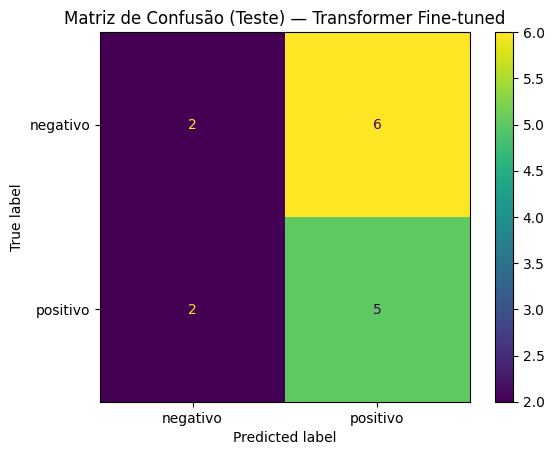

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = trainer.predict(test_tok)
y_pred = np.argmax(pred.predictions, axis=-1)

print(classification_report(
    y_test, y_pred,
    target_names=["negativo(0)", "positivo(1)"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negativo","positivo"]).plot()
plt.title("Matriz de Confusão (Teste) — Transformer Fine-tuned")
plt.show()

### Interpretação do resultado

Apesar do uso de um modelo Transformer, o desempenho no conjunto de teste
permanece instável. Isso ocorre porque o fine-tuning foi realizado com um
conjunto de dados muito pequeno, o que leva a alta variância e decisões enviesadas.

Esse resultado ilustra um ponto central da Análise de Sentimentos profissional:
Transformers não eliminam a necessidade de dados rotulados suficientes.

Em cenários com poucos exemplos, modelos clássicos (TF-IDF + classificadores lineares)
podem apresentar desempenho mais estável. O fine-tuning de Transformers torna-se
mais eficaz à medida que o volume e a diversidade de dados aumentam.
